# 05 - Geographic & Temporal Delay Patterns


## Setup




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = Path('../../data/raw data/DataCoSupplyChainDataset.csv')  

try:
    df = pd.read_csv(DATA_PATH, encoding='utf-8')
except UnicodeDecodeError:
    print("UTF-8 failed, falling back to ISO-8859-1")
    df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1')

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


UTF-8 failed, falling back to ISO-8859-1 (common for this dataset)
Shape: 180,519 rows x 53 columns


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## Geographic patterns

Delay rate (not just volume) by region and country.

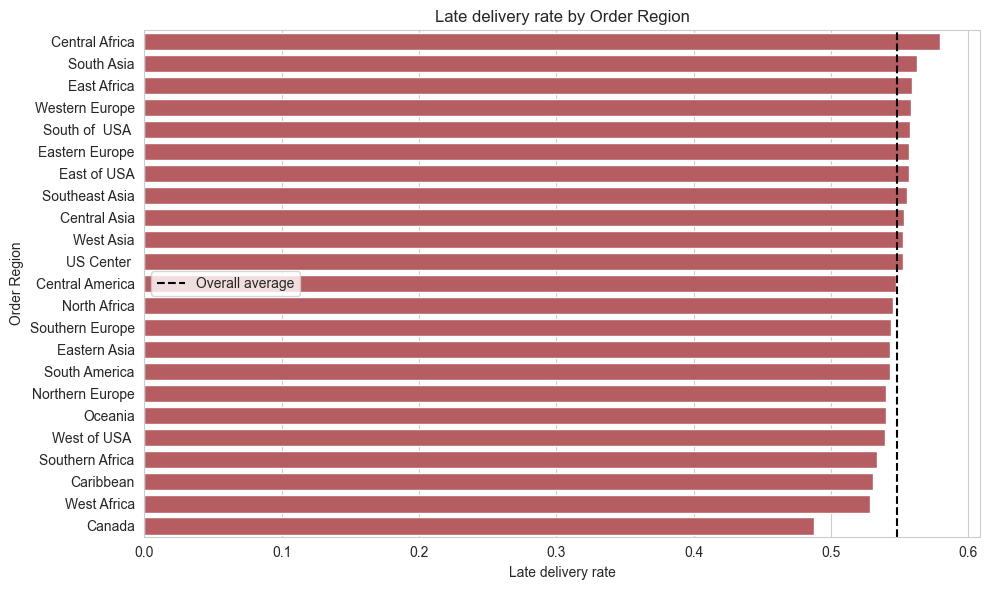

,Order Region,late_rate,n_orders
2,Central Africa,0.579606,1677
13,South Asia,0.562670,7731
5,East Africa,0.559395,1852
22,Western Europe,0.558486,27109
14,South of USA,0.557726,4045
8,Eastern Europe,0.556633,3920
6,East of USA,0.556616,6915
15,Southeast Asia,0.555299,9539
4,Central Asia,0.553345,553
20,West Asia,0.552837,6009


In [2]:
region_delay = df.groupby('Order Region')['Late_delivery_risk'].agg(['mean', 'count']).reset_index()
region_delay.columns = ['Order Region', 'late_rate', 'n_orders']
region_delay = region_delay.sort_values('late_rate', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=region_delay, y='Order Region', x='late_rate', color='#C44E52')
plt.axvline(df['Late_delivery_risk'].mean(), color='black', linestyle='--', label='Overall average')
plt.xlabel('Late delivery rate')
plt.title('Late delivery rate by Order Region')
plt.legend()
plt.tight_layout()
plt.show()

region_delay


In [7]:
country_delay = df.groupby('Order Country')['Late_delivery_risk'].agg(['mean', 'count']).reset_index()
country_delay.columns = ['Order Country', 'late_rate', 'n_orders']
country_delay_filtered = country_delay[country_delay['n_orders'] >= 100].sort_values('late_rate', ascending=False)

print("Top 10 highest late rate countries (min. 100 orders):")
display(country_delay_filtered.head(10))
print("\nTop 10 lowest late rate countries (min. 100 orders):")
display(country_delay_filtered.tail(10))


Top 10 highest late rate countries (min. 100 orders):


,Order Country,late_rate,n_orders
40,Ecuador,0.670068,294
100,Mozambique,0.639344,244
109,Níger,0.638889,108
135,Somalia,0.638298,141
68,Hungría,0.625698,179
92,Malasia,0.612132,544
36,Costa de Marfil,0.607004,257
72,Irlanda,0.606925,491
56,Ghana,0.606061,264
26,Camboya,0.605263,152



Top 10 lowest late rate countries (min. 100 orders):


,Order Country,late_rate,n_orders
91,Madagascar,0.496644,149
118,Portugal,0.492711,343
28,Canada,0.488008,959
80,Kenia,0.487395,238
52,Finlandia,0.479310,290
86,Libia,0.466667,105
39,Dinamarca,0.449123,285
130,Senegal,0.441065,263
27,Camerún,0.440000,275
149,Togo,0.368852,122


**What we found (geographic):**

- **At the region level, the spread is fairly narrow** - from Canada's 48.8% late rate (lowest) up to Central Africa's 58.0% (highest), a range of about 9 percentage points around the overall 54.8% average. Most regions cluster fairly close to the average, so `Order Region` alone looks like a moderate, not dominant, predictor.
- **At the country level, the spread is much wider** - Ecuador tops out at 67.0% late, while Togo sits at 36.9%, a ~30 percentage point range. This suggests `Order Country` carries meaningfully more granular signal than region - worth prioritising in feature engineering, potentially via the target encoded regional/country delay rate feature already planned in our workflow.
- **Caveat worth noting honestly:** the country level numbers are filtered to a minimum of 100 orders, but some of the standout countries (e.g. Togo at n=122, Níger at n=108) are still fairly close to that threshold. These rates are based on relatively small samples and could be somewhat noisy - we should be cautious about treating them as strongly reliable signals versus larger sample countries.
- **A genuine data quality finding worth flagging separately:** `Order Country` values are inconsistently localized - some appear in English (Ghana, Portugal, Canada) and others in Spanish (Hungría, Malasia, Irlanda, Camboya, Kenia, Finlandia, Dinamarca, Camerún, "Costa de Marfil" for Ivory Coast, "Níger" for Niger). This is a categorical standardization issue for Stage 3 - worth checking whether any country appears twice under two different spellings/languages (which would silently split one country's data into two categories and weaken its signal). This ties directly to the "Categorical Standardization" preprocessing step already planned in our Initial Submission.
- **Responsible AI flag:** Central Africa, South Asia, and East Africa show the highest regional late rates. Since our secondary lens uses risk score to drive operational prioritisation, it's worth stating explicitly in our recommendation that region linked risk should inform *proactive logistics support* (e.g. reviewing carrier routes to that region), not be used as a reason to deprioritise service to customers in those regions - this is the responsible AI check we flagged early in project framing, now grounded in a real finding rather than a hypothetical.

**Log for `DECISION_LOG.md`:** country level delay rate is a stronger candidate feature than region level; flag the country name language inconsistency for Stage 3 standardization before encoding.


## Temporal patterns

Delay rate by year, day of week, month - informs both feature engineering and the chronological split decision.

In [4]:
date_col_candidates = [c for c in df.columns if 'order date' in c.lower()]
print("Detected order date column(s):", date_col_candidates)
order_date_col = date_col_candidates[0]

df['order_datetime'] = pd.to_datetime(df[order_date_col], errors='coerce')
df['order_year'] = df['order_datetime'].dt.year
df['order_month'] = df['order_datetime'].dt.month
df['order_dayofweek'] = df['order_datetime'].dt.day_name()
df['order_hour'] = df['order_datetime'].dt.hour

print(f"Date range: {df['order_datetime'].min()} to {df['order_datetime'].max()}")


Detected order date column(s): ['order date (DateOrders)']
Date range: 2015-01-01 00:00:00 to 2018-01-31 23:38:00


In [5]:
yearly_delay = df.groupby('order_year')['Late_delivery_risk'].agg(['mean', 'count'])
print("Late delivery rate by year (checks for drift — relevant to split-strategy decision):")
yearly_delay


Late delivery rate by year (checks for drift — relevant to split-strategy decision):


,mean,count
order_year,,
2015,0.548635,62650
2016,0.550695,62550
2017,0.544477,53196
2018,0.562883,2123


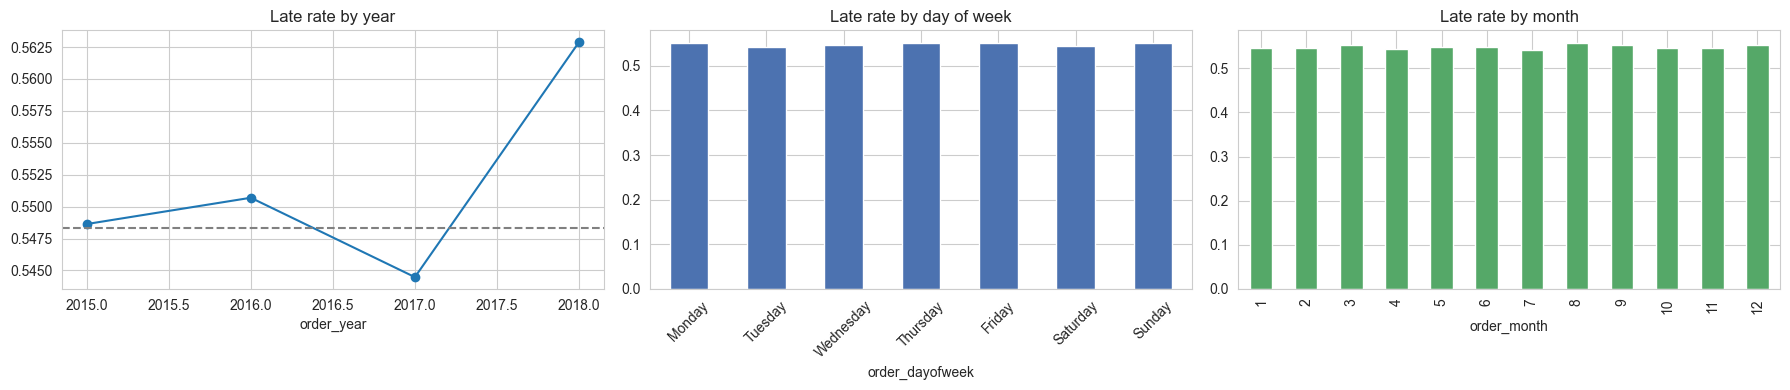

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

df.groupby('order_year')['Late_delivery_risk'].mean().plot(kind='line', marker='o', ax=ax[0])
ax[0].set_title('Late rate by year')
ax[0].axhline(df['Late_delivery_risk'].mean(), color='gray', linestyle='--')

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df.groupby('order_dayofweek')['Late_delivery_risk'].mean().reindex(dow_order).plot(kind='bar', ax=ax[1], color='#4C72B0')
ax[1].set_title('Late rate by day of week')
ax[1].tick_params(axis='x', rotation=45)

df.groupby('order_month')['Late_delivery_risk'].mean().plot(kind='bar', ax=ax[2], color='#55A868')
ax[2].set_title('Late rate by month')

plt.tight_layout()
plt.show()


**What we found (temporal):**

- **Date range confirmed: January 2015 to January 2018.** Note the 2018 slice is very thin - only 2,123 orders (a single month, January) compared to ~62,500–63,000 orders in each of 2015 and 2016, and 53,196 in 2017. This matters a lot for our split strategy decision.
- **Late rate by year is essentially stable: 54.86% (2015), 55.07% (2016), 54.45% (2017), 56.29% (2018, but this is a tiny, single month sample).** All four years sit within about a 2 percentage point band of each other - there's **no meaningful year over year drift** in the underlying delay rate.
- **Day of week and month show almost no variation at all** - both charts are visually flat, with late rate hovering in a narrow band around 53–55% across every day and every month, no clear weekday/weekend effect and no obvious seasonal spike (e.g. no holiday season surge visible). This is itself a useful negative finding: it tells us calendar based features (day of week, month, "is holiday season") are **unlikely to be strong predictors** on their own, so we shouldn't expect much lift from them in Stage 4 - worth deprioritising fancy seasonality feature engineering in favour of the stronger geographic/shipping-mode signals found elsewhere.

**Direct implication for our open split strategy decision (random vs. chronological):**

This finding actually complicates the split decision in a useful way, rather than simply resolving it:

- **The case for chronological splitting weakens somewhat on "drift" grounds** - since late rate is stable across 2015–2017, a chronological split isn't rescuing us from some big pattern shift the way it would if drift were present.
- **But a naive chronological split (train on 2015–2017, test on 2018) is now clearly a bad idea in practice** - the 2018 slice is only one month (January) and just 2,123 rows, which is both too small and too seasonally narrow (only one month) to be a reliable, representative test set on its own.
- **Recommended resolution:** rather than splitting strictly by calendar year, use a **chronological split by proportion of the full timeline** - e.g. sort all orders by `order date` and take the most recent ~15–20% as the test set (which would span roughly the second half of 2017 through January 2018), rather than isolating just the thin 2018 tail. This keeps the "test on the future, not a random shuffle" principle intact (still realistic for deployment) while avoiding an unreasonably small or seasonally biased test set.

**`DECISION_LOG.md`:** stability across years checked (no meaningful drift found); final split strategy chosen as proportion based chronological split (last ~15-20% of orders by date) rather than a strict calendar year cutoff, specifically because the raw 2018 slice is too small and seasonally narrow to serve as a standalone test set.
